# TP1 (modelos de regresión) — resolución de Ramiro

Notebook generado a partir de `TP1 ramiro.py`.

El objetivo del TP es predecir el peso del bebé al nacer (`weight`, en libras) mediante regresión lineal, evaluando los modelos con las métricas MAE y R².

Los datos (`X_train.csv`, `y_train.csv`, `X_test.csv`) se encuentran en la misma carpeta que este notebook, por lo que se cargan por ruta relativa.

# Carga de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Armado de los DataFrames:
predictores = pd.read_csv("X_train.csv")
var_ind = pd.read_csv("y_train.csv")["weight"]
X_test = pd.read_csv("X_test.csv")

print("--- Predictores:")
print(predictores)
print("\n--- Variable independiente:")
print(var_ind)

--- Predictores:
     fage  mage       mature  visits  gained     sex      habit      marital  \
0    34.0    34  younger mom    14.0    28.0    male  nonsmoker      married   
1    36.0    31  younger mom    12.0    41.0  female  nonsmoker      married   
2    37.0    36   mature mom    10.0    28.0  female  nonsmoker      married   
3    32.0    31  younger mom    12.0    48.0  female  nonsmoker      married   
4    32.0    26  younger mom    14.0    45.0  female  nonsmoker      married   
..    ...   ...          ...     ...     ...     ...        ...          ...   
670  36.0    31  younger mom    15.0    28.0    male  nonsmoker  not married   
671  33.0    26  younger mom    13.0    34.0  female  nonsmoker      married   
672  37.0    31  younger mom     8.0    33.0  female  nonsmoker      married   
673  27.0    27  younger mom     7.0    25.0  female  nonsmoker      married   
674  21.0    17  younger mom    12.0    41.0  female  nonsmoker  not married   

      whitemom  
0    

# Exploración de los datos: distribución del peso de los bebés al nacer

Estadísticos de la variable a predecir:

In [ ]:
media = np.mean(var_ind)
varianza = np.var(var_ind)
desviacion = np.std(var_ind)
mediana = np.median(var_ind)

print("- Media:", media)
print("- Mediana:", mediana)
print("- Varianza:", varianza)
print("- Desviación estándar:", desviacion)

- Media: 7.2657185185185185
- Mediana: 7.31
- Varianza: 1.475578854101509
- Desviación estándar: 1.214734067235092


Verificación de distribución normal por los tests de Kolmogorov-Smirnov y Shapiro-Wilk (los respectivos códigos en Python fueron escritos con asistencia de ChatGPT):

In [ ]:
resultado = stats.kstest(
    var_ind,
    stats.norm(np.mean(var_ind), np.std(var_ind)).cdf
)

print("- Estadístico K-S:", resultado.statistic)
print("- p-valor:", resultado.pvalue)

# Shapiro-Wilk
resultado = stats.shapiro(var_ind)

print("\n- Estadístico Shapiro-Wilk:", resultado.statistic)
print("- p-valor:", resultado.pvalue)

- Estadístico K-S: 0.05706290442253159
- p-valor: 0.02369477301048961

- Estadístico Shapiro-Wilk: 0.9691337450125208
- p-valor: 1.0011989237450919e-10


En ambos tests, el p-value resulta < 0,05, por lo que se rechaza la hipótesis nula que plantea que los datos siguen una distribución normal.

## Histograma

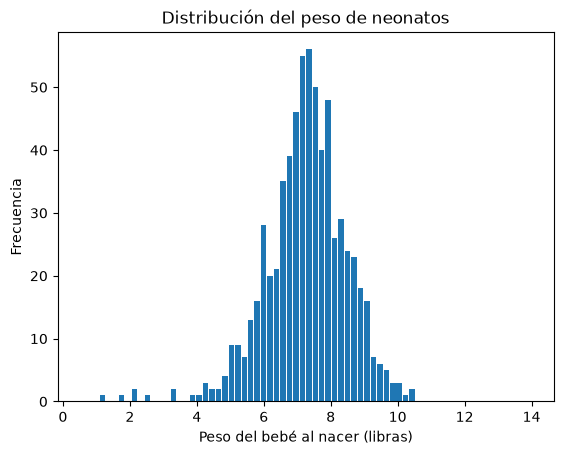

In [ ]:
plt.hist(var_ind, bins=70, range=[0.5, 14], rwidth=0.85)

plt.xlabel("Peso del bebé al nacer (libras)")
plt.ylabel("Frecuencia")
plt.title("Distribución del peso de neonatos")

plt.show()

Visualmente, el histograma se aproxima a una distribución normal. Es bastante simétrico, algo que también se interpreta al comparar la media con la mediana.

# Análisis de distribuciones de los predictores

## Predictores numéricos: fage, mage, visits y gained

Caracterización:

             fage        mage      visits      gained
count  675.000000  675.000000  675.000000  675.000000
mean    31.054815   28.789630   11.743704   30.789630
std      6.801223    5.522563    3.935432   15.592936
min     15.000000   14.000000    0.000000    0.000000
25%     26.000000   25.000000   10.000000   20.000000
50%     31.000000   29.000000   12.000000   30.000000
75%     35.000000   33.000000   14.000000   38.000000
max     53.000000   43.000000   30.000000   98.000000


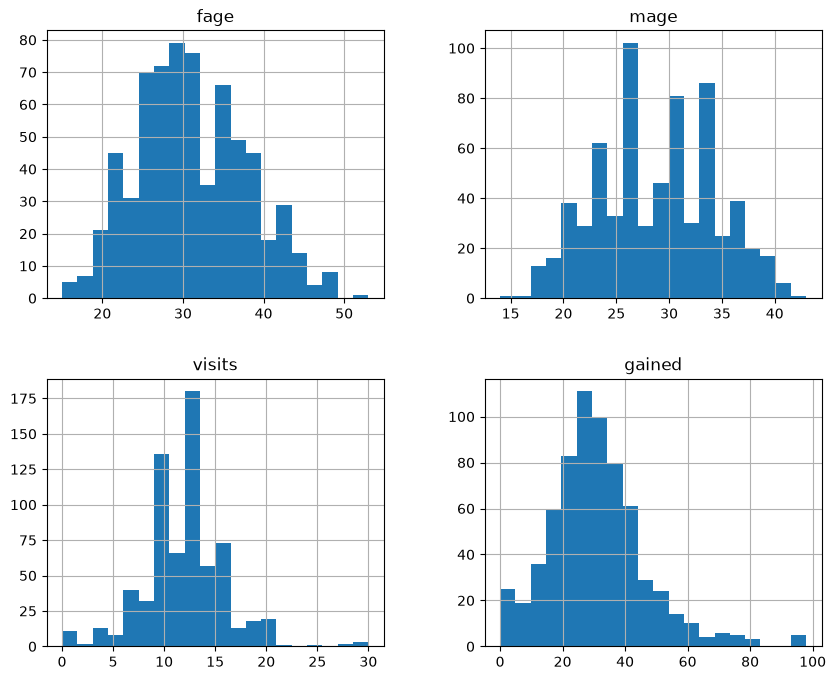

In [ ]:
print(predictores[["fage", "mage", "visits", "gained"]].describe())

predictores[["fage", "mage", "visits", "gained"]].hist(
    bins=20,
    figsize=(10, 8)
)

plt.show()

Análisis de normalidad (test de Shapiro-Wilk):

In [ ]:
resultado_fage = stats.shapiro(predictores["fage"])
resultado_mage = stats.shapiro(predictores["mage"])
resultado_visits = stats.shapiro(predictores["visits"])
resultado_gained = stats.shapiro(predictores["gained"])

print("- fage:", resultado_fage)
print("- mage:", resultado_mage)
print("- visits:", resultado_visits)
print("- gained:", resultado_gained)

- fage: ShapiroResult(statistic=np.float64(0.9898841425248859), pvalue=np.float64(0.00013432167432166894))
- mage: ShapiroResult(statistic=np.float64(0.9881267919068982), pvalue=np.float64(2.74203284588859e-05))
- visits: ShapiroResult(statistic=np.float64(0.9518601704272457), pvalue=np.float64(4.892563241831919e-14))
- gained: ShapiroResult(statistic=np.float64(0.9525271454777701), pvalue=np.float64(6.325174705930823e-14))


Ninguno de los predictores (numéricos) sigue una distribución normal (p < 0,05). Sin embargo, tanto de los gráficos como de la comparación de las medias y medianas surge que estas variables siguen distribuciones bastante simétricas.

## Predictores categóricos: mature, sex, habit, marital y whitemom

In [ ]:
variables_cat = ["mature", "sex", "habit", "marital", "whitemom"]

for variable in variables_cat:
    #print(variable)
    print(predictores[variable].value_counts())
    print()

mature
younger mom    567
mature mom     108
Name: count, dtype: int64

sex
female    338
male      337
Name: count, dtype: int64

habit
nonsmoker    622
smoker        53
Name: count, dtype: int64

marital
married        450
not married    225
Name: count, dtype: int64

whitemom
white        535
not white    140
Name: count, dtype: int64



# Análisis de la distribución de la variable independiente según cada predictor categórico

Se pidió a ChatGPT que escribiera el código en Python para la clasificación y obtención de parámetros y análisis estadístico (t-test). Importante: para los tests estadísticos se asumió homocedasticidad en todos los casos.

## Influencia del sexo del bebé en su peso al nacer

Se ven diferencias en las medias y medianas entre los distintos sexos:

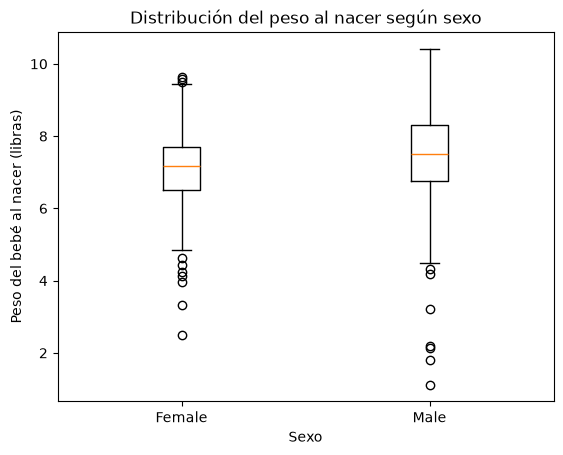

Peso según sexo:

Female:
count    338.000000
mean       7.078284
std        1.068426
min        2.500000
25%        6.500000
50%        7.160000
75%        7.690000
max        9.630000
Name: weight, dtype: float64

Male:
count    337.000000
mean       7.453709
std        1.322352
min        1.120000
25%        6.750000
50%        7.500000
75%        8.310000
max       10.420000
Name: weight, dtype: float64
- Estadístico t: -4.0575838325766185
- p-value: 5.5399189145474656e-05


In [ ]:
plt.boxplot(
    [
        var_ind[predictores["sex"] == "female"],
        var_ind[predictores["sex"] == "male"]
    ],
    tick_labels=["Female", "Male"]
)

plt.xlabel("Sexo")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según sexo")

plt.show()

print("Peso según sexo:")

print("\nFemale:")
print(var_ind[predictores["sex"] == "female"].describe())

print("\nMale:")
print(var_ind[predictores["sex"] == "male"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["sex"] == "female"],
    var_ind[predictores["sex"] == "male"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

Efectivamente, el peso de los varones es significativamente mayor al de las mujeres en esta muestra al momento de nacer (p < 0,001).

## Influencia de la edad de la madre en el peso del bebé al nacer

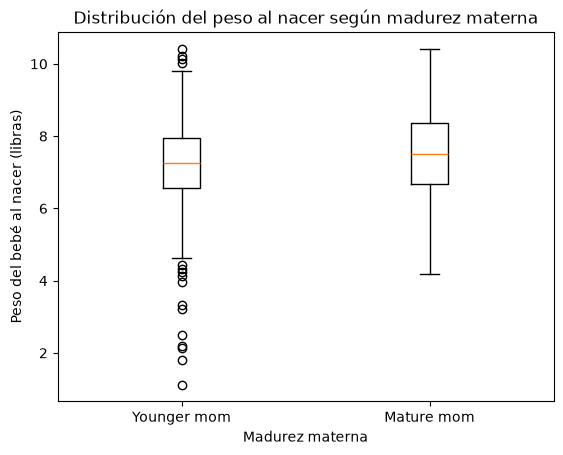

Peso según madurez materna:

Younger mom:
count    567.000000
mean       7.216684
std        1.206744
min        1.120000
25%        6.570000
50%        7.250000
75%        7.940000
max       10.420000
Name: weight, dtype: float64

Mature mom:
count    108.000000
mean       7.523148
std        1.235262
min        4.190000
25%        6.677500
50%        7.505000
75%        8.372500
max       10.410000
Name: weight, dtype: float64
- Estadístico t: -2.4097432970143
- p-value: 0.01623110664691753


In [ ]:
plt.boxplot(
    [
        var_ind[predictores["mature"] == "younger mom"],
        var_ind[predictores["mature"] == "mature mom"]
    ],
    tick_labels=["Younger mom", "Mature mom"]
)

plt.xlabel("Madurez materna")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según madurez materna")

plt.show()

print("Peso según madurez materna:")

print("\nYounger mom:")
print(var_ind[predictores["mature"] == "younger mom"].describe())

print("\nMature mom:")
print(var_ind[predictores["mature"] == "mature mom"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["mature"] == "younger mom"],
    var_ind[predictores["mature"] == "mature mom"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

Se encontraron diferencias estadísticamente significativas en el peso al nacer según la edad materna (p < 0,05). Los hijos de madres de 35 años o más presentaron un mayor peso promedio que los hijos de madres menores de 35 años.

## Distribución del peso según hábito de fumar

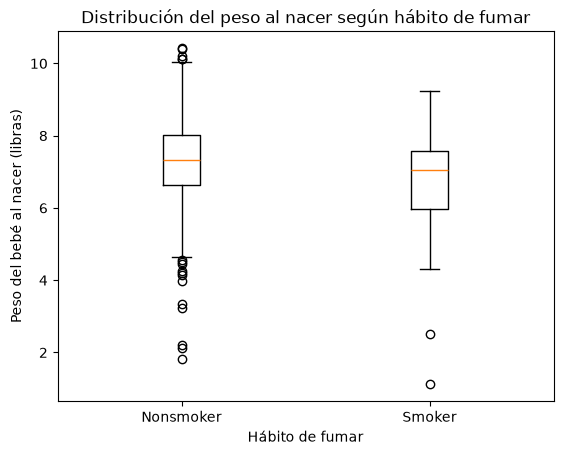

Peso según hábito de fumar:

Nonsmoker:
count    622.000000
mean       7.310707
std        1.178290
min        1.810000
25%        6.645000
50%        7.340000
75%        8.017500
max       10.420000
Name: weight, dtype: float64

Smoker:
count    53.000000
mean      6.737736
std       1.505160
min       1.120000
25%       5.960000
50%       7.060000
75%       7.580000
max       9.250000
Name: weight, dtype: float64
- Estadístico t: 3.3182777191912742
- p-value: 0.0009545248662209945


In [ ]:
plt.boxplot(
    [
        var_ind[predictores["habit"] == "nonsmoker"],
        var_ind[predictores["habit"] == "smoker"]
    ],
    tick_labels=["Nonsmoker", "Smoker"]
)

plt.xlabel("Hábito de fumar")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según hábito de fumar")

plt.show()

print("Peso según hábito de fumar:")

print("\nNonsmoker:")
print(var_ind[predictores["habit"] == "nonsmoker"].describe())

print("\nSmoker:")
print(var_ind[predictores["habit"] == "smoker"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["habit"] == "nonsmoker"],
    var_ind[predictores["habit"] == "smoker"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

Nuevamente, el hecho de que la madre fume afecta el peso del bebé al nacer (p < 0,001). En este sentido, los bebés de madres fumadoras presentaron un peso promedio significativamente menor respecto de aquellos de madres no fumadoras.

## Influencia del estado civil de los progenitores en el peso del neonato

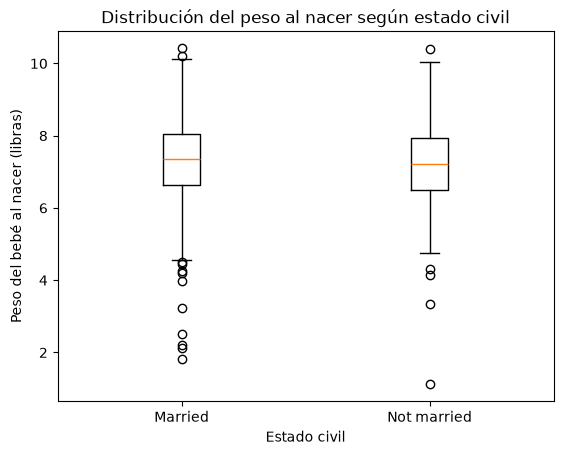

Peso según estado civil:

Married:
count    450.000000
mean       7.303111
std        1.242776
min        1.810000
25%        6.640000
50%        7.365000
75%        8.060000
max       10.420000
Name: weight, dtype: float64

Not married:
count    225.000000
mean       7.190933
std        1.158531
min        1.120000
25%        6.500000
50%        7.220000
75%        7.940000
max       10.410000
Name: weight, dtype: float64
- Estadístico t: 1.130417334578761
- p-value: 0.2587031076084956


In [ ]:
plt.boxplot(
    [
        var_ind[predictores["marital"] == "married"],
        var_ind[predictores["marital"] == "not married"]
    ],
    tick_labels=["Married", "Not married"]
)

plt.xlabel("Estado civil")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según estado civil")

plt.show()

print("Peso según estado civil:")

print("\nMarried:")
print(var_ind[predictores["marital"] == "married"].describe())

print("\nNot married:")
print(var_ind[predictores["marital"] == "not married"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["marital"] == "married"],
    var_ind[predictores["marital"] == "not married"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

El estado marital de la madre no afectaría el peso del bebé al nacer.

## Distribución del peso según "raza" de la madre

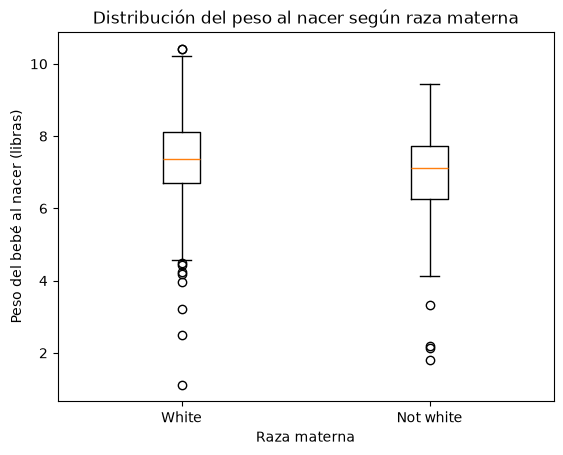

Peso según raza materna:

White:
count    535.000000
mean       7.348879
std        1.183671
min        1.120000
25%        6.690000
50%        7.370000
75%        8.125000
max       10.420000
Name: weight, dtype: float64

Not white:
count    140.000000
mean       6.947929
std        1.286348
min        1.810000
25%        6.250000
50%        7.120000
75%        7.720000
max        9.430000
Name: weight, dtype: float64
- Estadístico t: 3.5033048175358164
- p-value: 0.0004899430036055833


In [ ]:
plt.boxplot(
    [
        var_ind[predictores["whitemom"] == "white"],
        var_ind[predictores["whitemom"] == "not white"]
    ],
    tick_labels=["White", "Not white"]
)

plt.xlabel("Raza materna")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Distribución del peso al nacer según raza materna")

plt.show()

print("Peso según raza materna:")

print("\nWhite:")
print(var_ind[predictores["whitemom"] == "white"].describe())

print("\nNot white:")
print(var_ind[predictores["whitemom"] == "not white"].describe())

resultado_ttest = stats.ttest_ind(
    var_ind[predictores["whitemom"] == "white"],
    var_ind[predictores["whitemom"] == "not white"]
)

print("- Estadístico t:", resultado_ttest.statistic)
print("- p-value:", resultado_ttest.pvalue)

Se encontraron diferencias estadísticamente significativas en el peso al nacer según la categoría de raza materna. Los hijos de madres clasificadas como white presentaron un peso promedio mayor que aquellos de madres clasificadas como not white (p < 0,001).

### En resumen

Los predictores categóricos sex, mature, habit y whitemom influyen significativamente en el peso del bebé (p < 0,05). No hay evidencia suficiente para afirmar que el estado marital también lo haga.

# Análisis de correlación entre los predictores (individualmente) y el peso al nacer

## Edad del padre y peso del hijo al nacer


Correlación de Pearson:


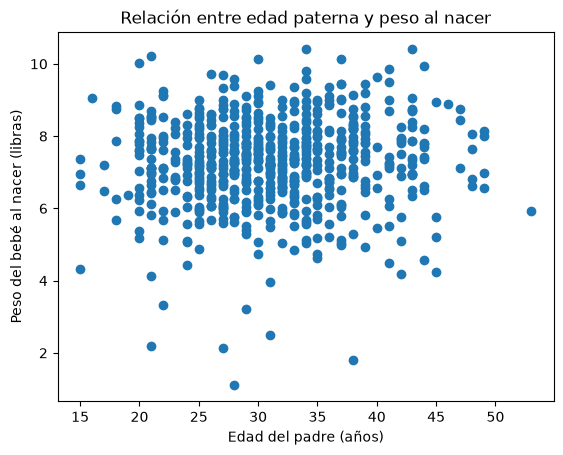

- Coeficiente de correlación: 0.05962825041005415
- p-value: 0.12169613358863411


In [ ]:
plt.scatter(predictores["fage"], var_ind)

plt.xlabel("Edad del padre (años)")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre edad paterna y peso al nacer")

print("\nCorrelación de Pearson:")

plt.show()

resultado = stats.pearsonr(predictores["fage"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

La correlación fue positiva, pero de muy baja magnitud. El p-value indica que no hay correlación lineal estadísticamente significativa.

## Edad de la madre y peso del hijo al nacer

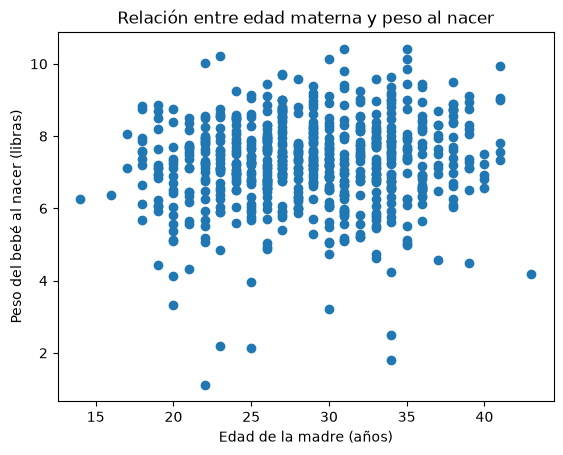


Correlación de Pearson:
- Coeficiente de correlación: 0.10420953308219373
- p-value: 0.00673225215402289


In [ ]:
plt.scatter(predictores["mage"], var_ind)

plt.xlabel("Edad de la madre (años)")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre edad materna y peso al nacer")

plt.show()

print("\nCorrelación de Pearson:")

resultado = stats.pearsonr(predictores["mage"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

Existe una correlación positiva y estadísticamente significativa entre la edad materna y el peso promedio del bebé al nacer (p < 0,01). Sin embargo, la magnitud de la correlación fue baja, lo que indica una asociación lineal débil.

## Relación entre el número de visitas al obstetra y el peso del hijo al nacer

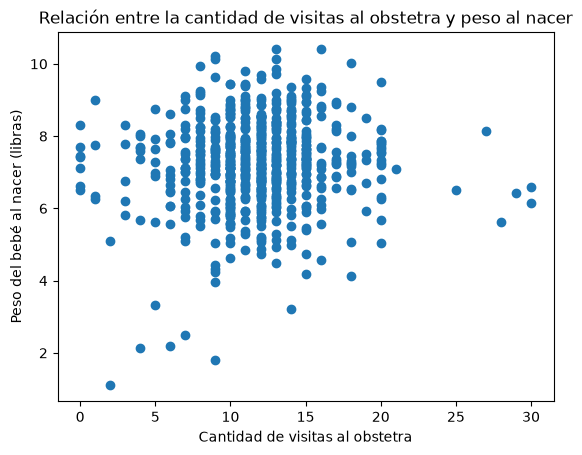


Correlación de Pearson:
- Coeficiente de correlación: 0.07485288692083707
- p-value: 0.05191254669074245


In [ ]:
plt.scatter(predictores["visits"], var_ind)

plt.xlabel("Cantidad de visitas al obstetra")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre la cantidad de visitas al obstetra y peso al nacer")

plt.show()

print("\nCorrelación de Pearson:")

resultado = stats.pearsonr(predictores["visits"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

No se observó una correlación lineal estadísticamente significativa entre la cantidad de visitas al obstetra y el peso al nacer. La correlación es positiva, pero de muy baja magnitud.

## Correlación entre el peso corporal ganado por la madre y el peso del hijo al nacer

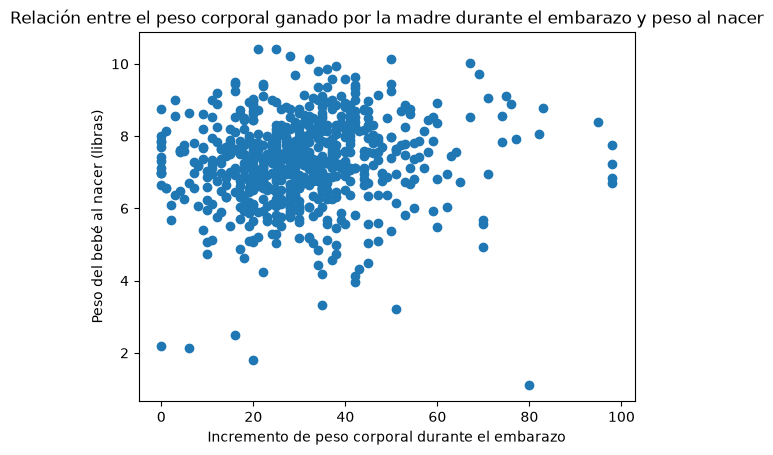


Correlación de Pearson:
- Coeficiente de correlación: 0.09928096371255103
- p-value: 0.009851641800050197


In [ ]:
plt.scatter(predictores["gained"], var_ind)

plt.xlabel("Incremento de peso corporal durante el embarazo")
plt.ylabel("Peso del bebé al nacer (libras)")
plt.title("Relación entre el peso corporal ganado por la madre durante el embarazo y peso al nacer")

plt.show()

print("\nCorrelación de Pearson:")

resultado = stats.pearsonr(predictores["gained"], var_ind)

print("- Coeficiente de correlación:", resultado.statistic)
print("- p-value:", resultado.pvalue)

Se observó una correlación positiva y estadísticamente significativa entre el aumento de peso materno y el peso al nacer (p < 0,01). No obstante, la magnitud de la correlación fue muy baja, indicando una asociación lineal débil entre ambas variables.

# Construcción del modelo

Primeramente, las variables categóricas se convierten en binarias y se agregan como nuevas series al DataFrame de predictores.

In [ ]:
predictores["mature_bin"] = predictores["mature"].map({
    "younger mom": 0,
    "mature mom": 1
})

predictores["sex_bin"] = predictores["sex"].map({
    "female": 0,
    "male": 1
})

predictores["habit_bin"] = predictores["habit"].map({
    "nonsmoker": 0,
    "smoker": 1
})

predictores["marital_bin"] = predictores["marital"].map({
    "not married": 0,
    "married": 1
})

predictores["whitemom_bin"] = predictores["whitemom"].map({
    "not white": 0,
    "white": 1
})

Luego, se dividen (aleatoriamente) los datos de modo de usar una parte (mayoritaria) para el entrenamiento -planteo del modelo-, y los restantes para la validación de la regresión lograda.

In [ ]:
from sklearn.model_selection import train_test_split

X_entrenamiento, X_validación, y_entrenamiento, y_validación = train_test_split(
    predictores,
    var_ind,
    test_size=0.20,
    random_state=42
)

print("Tamaño de X_entrenamiento:", X_entrenamiento.shape)
print("Tamaño de X_validación:", X_validación.shape)

print("\nTamaño de y_entrenamiento:", y_entrenamiento.shape)
print("Tamaño de y_validación:", y_validación.shape)

Tamaño de X_entrenamiento: (540, 14)
Tamaño de X_validación: (135, 14)

Tamaño de y_entrenamiento: (540,)
Tamaño de y_validación: (135,)


# Modelos

Cada modelo queda englobado en una función `construir_X_modelo_N(df)` que construye su matriz de features a partir del DataFrame de predictores. Todas se registran en el diccionario `modelos`, desde donde se las llama tanto para la evaluación en entrenamiento como desde la validación cruzada.

- **Modelo 1**: lineal con fage, mage, visits, gained, sex_bin, habit_bin, marital_bin, whitemom_bin, mature_bin.
- **Modelo 2**: lineal con mage, visits, gained, sex_bin, habit_bin, whitemom_bin.
- **Modelo 3**: lineal con mage, gained, habit_bin, whitemom_bin.
- **Modelo 4**: lineal con mage, gained, whitemom_bin.
- **Modelo 5**: lineal con features combinadas: visits/mage, gained, gained/visits, sex_bin·gained, habit_bin·gained, visits·mage.
- **Modelo 6**: lineal con mage, gained, habit_bin, whitemom_bin, marital_bin, sex_bin (excluyendo pesos extremos: weight < 4 libras).
- **Modelo 7**: polinómico de grado 2 con mage y gained: además de los términos lineales, incluye los términos cuadráticos y la interacción (mage², mage·gained, gained²).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

def construir_X_modelo_1(df):
    return np.array(df[["fage", "mage", "visits", "gained", "sex_bin", "habit_bin", "marital_bin", "whitemom_bin", "mature_bin"]])

def construir_X_modelo_2(df):
    return np.array(df[["mage", "visits", "gained", "sex_bin", "habit_bin", "whitemom_bin"]])

def construir_X_modelo_3(df):
    return np.array(df[["mage", "gained", "habit_bin", "whitemom_bin"]])

def construir_X_modelo_4(df):
    return np.array(df[["mage", "gained", "whitemom_bin"]])

def construir_X_modelo_5(df):
    visitas_seguras = df["visits"].replace(0.0, 1.0)
    return np.array(np.column_stack([
        df["visits"] / df["mage"],
        df["gained"],
        df["gained"] / visitas_seguras,
        df["sex_bin"] * df["gained"],
        df["habit_bin"] * df["gained"],
        df["visits"] * df["mage"],
    ]))

def construir_X_modelo_6(df):
    return np.array(df[["mage", "gained", "habit_bin", "whitemom_bin", "marital_bin", "sex_bin"]])

def construir_X_modelo_7(df):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    return poly.fit_transform(df[["mage", "gained"]])

modelos = {
    "Modelo 1": construir_X_modelo_1,
    "Modelo 2": construir_X_modelo_2,
    "Modelo 3": construir_X_modelo_3,
    "Modelo 4": construir_X_modelo_4,
    "Modelo 5": construir_X_modelo_5,
    "Modelo 6": construir_X_modelo_6,
    "Modelo 7": construir_X_modelo_7,
}

In [ ]:
resultados_entrenamiento = {}

for nombre, construir_X in modelos.items():
    X_df, y_serie = X_entrenamiento, y_entrenamiento

    if nombre == "Modelo 6":
        mascara = y_serie >= 4
        X_df, y_serie = X_df[mascara], y_serie[mascara]
        print(nombre, "-> casos excluidos (weight < 4 libras):", (~mascara).sum())

    X = construir_X(X_df)
    y = np.array(y_serie)

    reg = LinearRegression()
    reg.fit(X, y)
    y_pred = reg.predict(X)

    resultados_entrenamiento[nombre] = {
        "MAE": mean_absolute_error(y, y_pred),
        "R2": r2_score(y, y_pred),
    }

    print(nombre, "-> MAE:", resultados_entrenamiento[nombre]["MAE"], "| R²:", resultados_entrenamiento[nombre]["R2"])

Modelo 1 -> MAE: 0.8942809842529854 | R²: 0.09460493190627561
Modelo 2 -> MAE: 0.8967352798564867 | R²: 0.09125503406318558
Modelo 3 -> MAE: 0.91084422671847 | R²: 0.06566654348824308


Modelo 4 -> MAE: 0.9144510270474503 | R²: 0.04684935920998479
Modelo 5 -> MAE: 0.9018431457887203 | R²: 0.07025914946749356
Modelo 6 -> casos excluidos (weight < 4 libras): 8
Modelo 6 -> MAE: 0.8336168602975271 | R²: 0.09549606084894702


Modelo 7 -> MAE: 0.9204680735116041 | R²: 0.032105468128028614


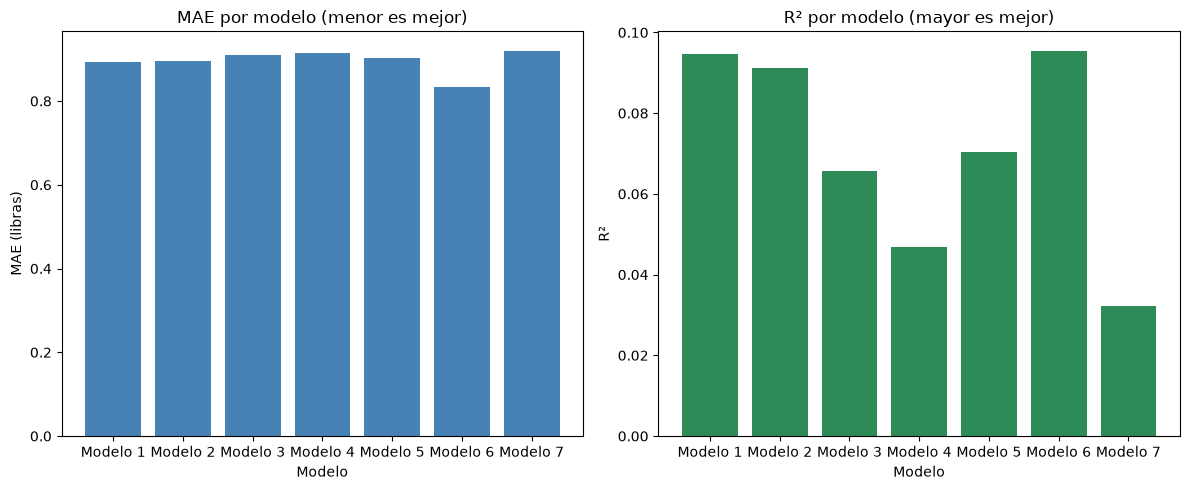

In [ ]:
nombres = list(modelos.keys())
MAE = [resultados_entrenamiento[n]["MAE"] for n in nombres]
R2 = [resultados_entrenamiento[n]["R2"] for n in nombres]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(nombres, MAE, color="steelblue")
ax1.set_title("MAE por modelo (menor es mejor)")
ax1.set_xlabel("Modelo")
ax1.set_ylabel("MAE (libras)")

ax2.bar(nombres, R2, color="seagreen")
ax2.set_title("R² por modelo (mayor es mejor)")
ax2.set_xlabel("Modelo")
ax2.set_ylabel("R²")

plt.tight_layout()
plt.show()

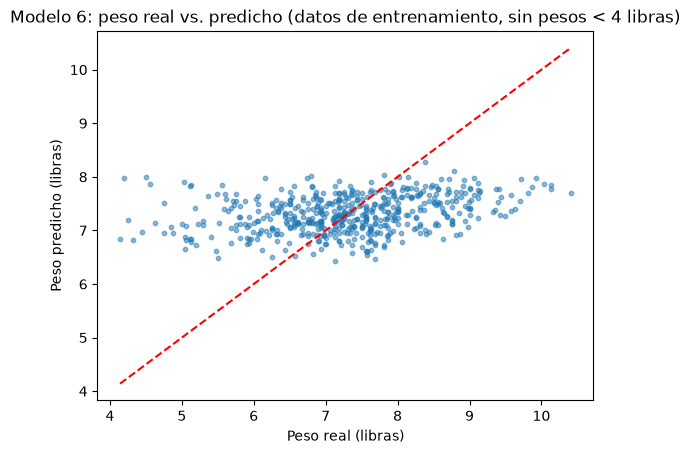

In [ ]:
mascara6 = y_entrenamiento >= 4
X6 = construir_X_modelo_6(X_entrenamiento[mascara6])
y6 = np.array(y_entrenamiento[mascara6])

reg6 = LinearRegression()
reg6.fit(X6, y6)
y6_pred = reg6.predict(X6)

plt.scatter(y6, y6_pred, s=10, alpha=0.5)

plt.xlabel("Peso real (libras)")
plt.ylabel("Peso predicho (libras)")
plt.title("Modelo 6: peso real vs. predicho (datos de entrenamiento, sin pesos < 4 libras)")

lims = [min(y6.min(), y6_pred.min()), max(y6.max(), y6_pred.max())]
plt.plot(lims, lims, "r--")

plt.show()

# Validación cruzada (5-fold)

Para estimar qué tan bien generaliza cada modelo, se divide el set de entrenamiento en quintos: cada modelo se entrena 5 veces, usando en cada una un 4/5 distinto de los datos, y se mide el MAE sobre el quinto restante (datos que el modelo no vio). Así se obtienen 5 valores de MAE por modelo, lo que permite visualizar el margen de diferencia (variabilidad) del error según qué datos toquen para entrenar.

Todas las funciones `construir_X_modelo_N` definidas en la sección Modelos se llaman desde acá: dentro de cada fold, cada función construye las features del fold y con ellas se entrena una regresión lineal.

A diferencia de los MAE de las secciones anteriores —calculados sobre los propios datos de entrenamiento— estos se miden sobre datos no vistos, por lo que constituyen una estimación más honesta del error de predicción y suelen resultar algo mayores. En el Modelo 6, los pesos < 4 libras se excluyen solo de la parte de entrenamiento de cada fold; el quinto de validación se evalúa completo.

El Modelo 7 es una regresión polinómica de grado 2 sobre mage y gained: los términos cuadráticos y la interacción se generan con `PolynomialFeatures` dentro de cada fold.

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

MAE_validacion_cruzada = {nombre: [] for nombre in modelos}

for nombre, construir_X in modelos.items():
    for indices_entrenamiento, indices_validacion in kf.split(X_entrenamiento):
        X_fold_ent = X_entrenamiento.iloc[indices_entrenamiento]
        X_fold_val = X_entrenamiento.iloc[indices_validacion]
        y_fold_ent = y_entrenamiento.iloc[indices_entrenamiento]
        y_fold_val = y_entrenamiento.iloc[indices_validacion]

        if nombre == "Modelo 6":
            mascara = y_fold_ent >= 4
            X_fold_ent, y_fold_ent = X_fold_ent[mascara], y_fold_ent[mascara]

        reg = LinearRegression()
        reg.fit(construir_X(X_fold_ent), np.array(y_fold_ent))
        y_pred = reg.predict(construir_X(X_fold_val))

        MAE_validacion_cruzada[nombre].append(mean_absolute_error(np.array(y_fold_val), y_pred))

tabla_folds = pd.DataFrame(MAE_validacion_cruzada, index=[f"Fold {i}" for i in range(1, 6)])

print("MAE por fold (validación cruzada 5-fold):")
display(tabla_folds.round(4))

resumen_cv = pd.DataFrame({
    "MAE medio": tabla_folds.mean(),
    "Desvío estándar": tabla_folds.std(),
    "Mínimo": tabla_folds.min(),
    "Máximo": tabla_folds.max(),
    "Margen (máx - mín)": tabla_folds.max() - tabla_folds.min(),
})

print("Resumen del MAE por modelo:")
display(resumen_cv.round(4))

MAE por fold (validación cruzada 5-fold):


,Modelo 1,Modelo 2,Modelo 3,Modelo 4,Modelo 5,Modelo 6,Modelo 7
Fold 1,1.0608,1.0642,1.0548,1.0642,1.0698,1.0617,1.0681
Fold 2,0.9379,0.9156,0.9502,0.9753,0.9617,0.9273,1.0286
Fold 3,0.7677,0.7753,0.7734,0.7670,0.7636,0.7437,0.7420
Fold 4,1.0441,1.0355,1.0466,0.9868,1.0086,0.9779,0.9934
Fold 5,0.8567,0.8586,0.8239,0.8313,0.8722,0.8413,0.8499


Resumen del MAE por modelo:


,MAE medio,Desvío estándar,Mínimo,Máximo,Margen (máx - mín)
Modelo 1,0.9335,0.1244,0.7677,1.0608,0.2932
Modelo 2,0.9298,0.1208,0.7753,1.0642,0.2890
Modelo 3,0.9298,0.1278,0.7734,1.0548,0.2814
Modelo 4,0.9249,0.1219,0.7670,1.0642,0.2971
Modelo 5,0.9352,0.1201,0.7636,1.0698,0.3063
Modelo 6,0.9104,0.1228,0.7437,1.0617,0.3180
Modelo 7,0.9364,0.1364,0.7420,1.0681,0.3261


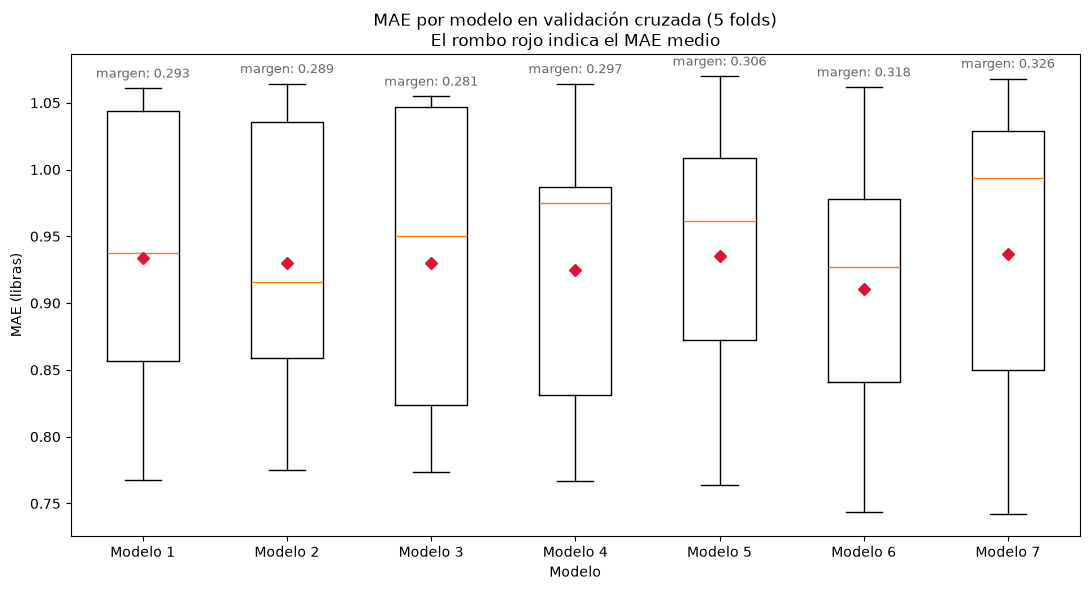

In [ ]:
plt.figure(figsize=(11, 6))

nombres = list(modelos.keys())
datos_mae = [MAE_validacion_cruzada[nombre] for nombre in nombres]

plt.boxplot(datos_mae, showmeans=True,
            meanprops=dict(marker="D", markerfacecolor="crimson", markeredgecolor="crimson"))
plt.xticks(range(1, len(nombres) + 1), nombres)

for i, mae_fold in enumerate(datos_mae, start=1):
    margen = max(mae_fold) - min(mae_fold)
    plt.text(i, max(mae_fold) + 0.008, f"margen: {margen:.3f}", ha="center", fontsize=9, color="dimgray")

plt.title("MAE por modelo en validación cruzada (5 folds)\nEl rombo rojo indica el MAE medio")
plt.xlabel("Modelo")
plt.ylabel("MAE (libras)")
plt.tight_layout()
plt.show()

## Modelo 8: ganador de la búsqueda exhaustiva original

Se incorpora el **modelo ID 16661**, primero en el ranking original de 33.343 modelos. Usa seis variables: fage, gained, sex_bin, habit_bin, marital_bin y whitemom_bin, más las interacciones sex_bin × marital_bin y marital_bin × whitemom_bin. Se ajusta mediante regresión lineal con intercepto, sin filtrar observaciones por su peso.

En la búsqueda original obtuvo MAE medio **0,886102** usando 5 folds sobre las **675 filas**. Aquí se evalúa con el protocolo del TP: split 80/20 con semilla 42 y 5 folds sobre las **540 filas de entrenamiento**, conservando el orden del split. Por eso los dos valores no se comparan directamente.

Las 135 filas reservadas no se evalúan en esta sección. El candidato fue elegido anteriormente con las 675 filas, por lo que esta comparación sigue siendo exploratoria. “Ganador de la búsqueda original” no implica ganador bajo el protocolo de Ramiro.

In [ ]:
def construir_X_modelo_8(df):
    return np.column_stack([
        df["fage"],
        df["gained"],
        df["sex_bin"],
        df["habit_bin"],
        df["marital_bin"],
        df["whitemom_bin"],
        df["sex_bin"] * df["marital_bin"],
        df["marital_bin"] * df["whitemom_bin"],
    ])

# Se agrega sin modificar las definiciones de los modelos anteriores.
modelos["Modelo 8"] = construir_X_modelo_8

In [ ]:
# Comprobar que se conserva el split y el orden usados en el TP.
indices_ent_m8, indices_res_m8 = train_test_split(
    np.arange(len(predictores)), test_size=0.20, random_state=42
)
np.testing.assert_array_equal(X_entrenamiento.index.to_numpy(), indices_ent_m8)
np.testing.assert_array_equal(y_entrenamiento.index.to_numpy(), indices_ent_m8)
assert len(X_entrenamiento) == 540
assert set(indices_ent_m8).isdisjoint(indices_res_m8)

# Error de entrenamiento: se informa separado del error de validación.
reg8 = LinearRegression()
reg8.fit(construir_X_modelo_8(X_entrenamiento), np.array(y_entrenamiento))
pred8_ent = reg8.predict(construir_X_modelo_8(X_entrenamiento))
print("Modelo 8 — entrenamiento:")
print("MAE:", mean_absolute_error(y_entrenamiento, pred8_ent))
print("R²:", r2_score(y_entrenamiento, pred8_ent))

# Los mismos 5 folds que los modelos 1–7; no se evalúa la reserva de 135 filas.
kf8 = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_folds_m8 = []
for fold, (idx_ent, idx_val) in enumerate(kf8.split(X_entrenamiento), start=1):
    X_fold_ent = X_entrenamiento.iloc[idx_ent]
    X_fold_val = X_entrenamiento.iloc[idx_val]
    y_fold_ent = y_entrenamiento.iloc[idx_ent]
    y_fold_val = y_entrenamiento.iloc[idx_val]

    reg_fold8 = LinearRegression()
    reg_fold8.fit(construir_X_modelo_8(X_fold_ent), np.array(y_fold_ent))
    pred_fold8 = reg_fold8.predict(construir_X_modelo_8(X_fold_val))
    resultados_folds_m8.append({
        "Fold": fold,
        "N entrenamiento": len(idx_ent),
        "N validación": len(idx_val),
        "MAE": mean_absolute_error(y_fold_val, pred_fold8),
        "R²": r2_score(y_fold_val, pred_fold8),
    })

tabla_folds_m8 = pd.DataFrame(resultados_folds_m8).set_index("Fold")
resumen_m8 = pd.DataFrame({
    "MAE medio": [tabla_folds_m8["MAE"].mean()],
    "Desvío MAE": [tabla_folds_m8["MAE"].std()],
    "R² medio": [tabla_folds_m8["R²"].mean()],
    "Desvío R²": [tabla_folds_m8["R²"].std()],
}, index=["Modelo 8"])

# Valores comprobados para estos CSV y estas particiones.
np.testing.assert_allclose(resumen_m8.loc["Modelo 8", "MAE medio"],
                           0.9191769722662467, atol=1e-10, rtol=0)
np.testing.assert_allclose(resumen_m8.loc["Modelo 8", "R² medio"],
                           0.011074550010982408, atol=1e-10, rtol=0)
print("\nModelo 8 — validación cruzada (5 folds):")
display(tabla_folds_m8.round(6))
display(resumen_m8.round(6))
print("R² medio es el promedio de los R² de cada fold; los desvíos no son intervalos de confianza.")

Modelo 8 — entrenamiento:
MAE: 0.885665319767639
R²: 0.09722495625288885

Modelo 8 — validación cruzada (5 folds):


,N entrenamiento,N validación,MAE,R²
Fold,,,,
1,432,108,1.037534,0.026572
2,432,108,0.970280,-0.003842
3,432,108,0.754688,0.034489
4,432,108,1.014515,-0.058734
5,432,108,0.818868,0.056888


,MAE medio,Desvío MAE,R² medio,Desvío R²
Modelo 8,0.919177,0.125327,0.011075,0.044674


R² medio es el promedio de los R² de cada fold; los desvíos no son intervalos de confianza.


In [ ]:
# Nueva comparación: conserva intactas las tablas y salidas anteriores.
tabla_folds_con_m8 = tabla_folds.copy()
tabla_folds_con_m8["Modelo 8"] = tabla_folds_m8["MAE"].to_numpy()
resumen_cv_con_m8 = pd.DataFrame({
    "MAE medio": tabla_folds_con_m8.mean(),
    "Desvío estándar": tabla_folds_con_m8.std(),
    "Mínimo": tabla_folds_con_m8.min(),
    "Máximo": tabla_folds_con_m8.max(),
}).sort_values("MAE medio")

print("Comparación de los 8 modelos con los mismos folds:")
display(resumen_cv_con_m8.round(6))

print("En estos folds, el Modelo 8 mejora al Modelo 1, pero el Modelo 6 conserva el menor MAE medio.")

Comparación de los 8 modelos con los mismos folds:


,MAE medio,Desvío estándar,Mínimo,Máximo
Modelo 6,0.910390,0.122768,0.743749,1.061720
Modelo 8,0.919177,0.125327,0.754688,1.037534
Modelo 4,0.924902,0.121918,0.767020,1.064154
Modelo 3,0.929768,0.127834,0.773417,1.054789
Modelo 2,0.929842,0.120836,0.775265,1.064235
Modelo 1,0.933451,0.124363,0.767666,1.060839
Modelo 5,0.935176,0.120058,0.763560,1.069849
Modelo 7,0.936410,0.136352,0.742011,1.068120


En estos folds, el Modelo 8 mejora al Modelo 1, pero el Modelo 6 conserva el menor MAE medio.
